In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
num_qubits = 12
num_layers = 4

In [3]:
import json

with open('data1.json', 'r') as file:
    data = json.load(file)

In [4]:
with open('datasmall.json', 'r') as file:
    data_small = json.load(file)

In [5]:
import qutip as qt

J = +1.0
h = +1.0

# Pauli matrices
X = qt.sigmax()
Z = qt.sigmaz()
I = qt.qeye(2)

# Initialize Hamiltonian terms
hamiltonian_terms = []

# Add cyclic ZZ terms
for i in range(num_qubits):
    zz_term = [J * qt.tensor([Z if j == i or j == (i+1)%num_qubits else I for j in range(num_qubits)])]
    hamiltonian_terms.extend(zz_term)

# Add X terms
for i in range(num_qubits):
    x_term = [h * qt.tensor([X if j == i else I for j in range(num_qubits)])]
    hamiltonian_terms.extend(x_term)

# Sum all terms
hamiltonian_qiskit = sum(hamiltonian_terms)
eigenvalues, eigenvectors = hamiltonian_qiskit.eigenstates()

In [6]:
energies1clp = [data[i]['energies_1'] for i in range(len(data))]
energies2clp = [data[i]['energies_2'] for i in range(len(data))]

gamma1clp = [data[i]['gammas_1'] for i in range(len(data))]
gamma2clp = [data[i]['gammas_2'] for i in range(len(data))]

In [7]:
energies = np.load('energies_vanilla.npy')
gamma_values = np.load('gamma_values_vanilla.npy')

errors = np.array([np.sum(gamma)*num_layers*2 for gamma in gamma_values])

In [8]:
errors1clp = [np.array(gamma1clp[i]).sum()*num_layers*2 for i in range(20)]
errors2clp = [np.array(gamma2clp[i]).sum()*num_layers*2 for i in range(20)]

In [51]:
errors1clp[:5]

[np.float64(0.42019696152306274),
 np.float64(0.8403939230461255),
 np.float64(1.2605908845691882),
 np.float64(1.680787846092251),
 np.float64(2.1009848076153137)]

In [9]:
energies_small = np.load('energies_small_vanilla.npy')
gamma_values_small = np.load('gamma_values_small_vanilla.npy')

In [10]:
e_noiseless = -15.040999640510218

In [11]:
errors_small = np.array([np.sum(gamma)*num_layers*2 for gamma in gamma_values_small])

In [12]:
errors_small

array([0.04445219, 0.06740735, 0.04190732, 0.07650542, 0.03916114,
       0.04533712, 0.05695098, 0.0411725 , 0.04364287, 0.06726384,
       0.06096084, 0.03577044, 0.07068289, 0.06524384, 0.04515732,
       0.05144377, 0.06094532, 0.05748185, 0.04246012, 0.06481565,
       0.04967299, 0.04711986, 0.05639719, 0.04874705])

In [47]:
errors1clp

[np.float64(0.42019696152306274),
 np.float64(0.8403939230461255),
 np.float64(1.2605908845691882),
 np.float64(1.680787846092251),
 np.float64(2.1009848076153137),
 np.float64(2.5211817691383764),
 np.float64(2.941378730661439),
 np.float64(3.361575692184502),
 np.float64(3.7817726537075647),
 np.float64(4.201969615230627),
 np.float64(4.62216657675369),
 np.float64(5.042363538276753),
 np.float64(5.462560499799816),
 np.float64(5.882757461322878),
 np.float64(6.302954422845941),
 np.float64(6.723151384369004),
 np.float64(7.143348345892067),
 np.float64(7.563545307415129),
 np.float64(7.983742268938192),
 np.float64(8.403939230461255)]

In [13]:
energies1clp_small = [data_small[i]['energies_1'] for i in range(len(data_small))]
energies2clp_small = [data_small[i]['energies_2'] for i in range(len(data_small))]

gamma1clp_small = [data_small[i]['gammas_1'] for i in range(len(data_small))]
gamma2clp_small = [data_small[i]['gammas_2'] for i in range(len(data_small))]

errors1clp_small = [np.array(gamma1clp_small[i]).sum()*num_layers*2 for i in range(len(gamma1clp_small))]
errors2clp_small = [np.array(gamma2clp_small[i]).sum()*num_layers*2 for i in range(len(gamma1clp_small))]

In [49]:
len(data_small)

5

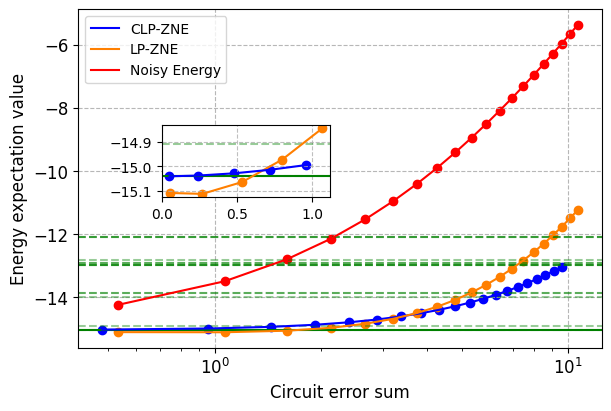

In [60]:
import matplotlib
plt.rcParams.update({
    "legend.fontsize": 10,                 # do not use external LaTeX
})
bs_clp = []
noisy_energies = []
font = {'weight' : 'normal', 'size'   : 12}
matplotlib.rc('font', **font)
fig, ax = plt.subplots(figsize=(6, 4), facecolor='w', edgecolor='k', constrained_layout=True)

plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.8)

for i in range(15):
    plt.axhline(y=e_noiseless + (eigenvalues[i] - eigenvalues[0]), color='green', linestyle='--', alpha=0.4)
plt.axhline(y=e_noiseless, color='green')

plt.xscale("log")

for i in range(20):
    x = np.array([errors1clp[i], errors2clp[i]])
    y = [np.mean(energies1clp[i]), np.mean(energies2clp[i])]
    m, b = np.polyfit(x, y, 1)
    bs_clp.append(b)
    
plt.plot([0.005 * (i + 1) * num_qubits * num_layers * 2 for i in range(20)], bs_clp, color='blue', label='CLP-ZNE')
plt.scatter([0.005 * (i + 1) * num_qubits * num_layers * 2 for i in range(20)], bs_clp, color='blue')

bs = []

for i in range(20):
    x = np.array((i+1)*errors)
    y = energies[i]
    y_noisy = np.mean(energies[i])
    noisy_energies.append(y_noisy)
    m, b = np.polyfit(x, y, 1)
    bs.append(b)
    
    
plt.plot([np.mean(errors)*(i + 1) for i in range(20)], bs, color='#ff7f00', label='LP-ZNE')#
plt.scatter([np.mean(errors)*(i + 1) for i in range(20)], bs, color='#ff7f00')
plt.plot([np.mean(errors)*(i + 1) for i in range(20)], noisy_energies, color='red', label='Noisy Energy')
plt.scatter([np.mean(errors)*(i + 1) for i in range(20)], noisy_energies, color='red')

plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.grid(axis='x', linestyle='--', alpha=0.9)
plt.xlabel('Circuit error sum')
plt.savefig("zne_large_noise.pdf", format="pdf", bbox_inches="tight")
plt.ylabel('Energy expectation value')
plt.legend()
    
inset_ax = fig.add_axes([0.26, 0.52, 0.28, 0.18
                        ])
inset_ax.grid(axis='y', linestyle='--', alpha=0.8)
inset_ax.grid(axis='x', linestyle='--', alpha=0.8)

for i in range(2):
    inset_ax.axhline(y=e_noiseless + (eigenvalues[i] - eigenvalues[0]), color='green', linestyle='--', alpha=0.4)
    
bs_lp_small = []
bs_clp_small = []
for j, i in enumerate([1, 5, 10, 15, 20]):
    x = errors_small*i
    y = energies[j]
    m, b = np.polyfit(x, y, 1)
    bs_lp_small.append(b)
    
    x = np.array([errors1clp_small[j], errors2clp_small[j]])
    y = [np.mean(energies1clp_small[j]), np.mean(energies2clp_small[j])]
    m, b = np.polyfit(x, y, 1)
    bs_clp_small.append(b)
    
inset_ax.tick_params(axis='both', which='major', labelsize=10)
    
inset_ax.axhline(y=e_noiseless, color='green')
inset_ax.plot([np.mean(errors_small)*i for i in [1, 5, 10, 15, 20]], bs_lp_small, color='#ff7f00')#
inset_ax.scatter([np.mean(errors_small)*i for i in [1, 5, 10, 15, 20]], bs_lp_small, color='#ff7f00')

inset_ax.plot([0.0005 * i * num_qubits * num_layers * 2 for i in [1, 5, 10, 15, 20]], bs_clp_small, color='blue')#
inset_ax.scatter([0.0005 * i * num_qubits * num_layers * 2 for i in [1, 5, 10, 15, 20]], bs_clp_small, color='blue')

plt.savefig('zne_large_noise_lp.pdf', format="pdf", bbox_inches="tight")

plt.show()